# 02 — Pipeline de Traitement du Déséquilibre
**Binôme B** | Credit Card Fraud Detection

### Ce notebook produit :
- `src/imbalance.py` — fonctions réutilisables par toute l'équipe
- Comparaison documentée : approche algorithmique vs approche données

### Plan :
1. Chargement des splits (produits par Binôme A)
2. Approche algorithmique — `class_weight`
3. Approche données — SMOTE, ADASYN, NearMiss
4. Comparaison visuelle et quantitative
5. Export de `src/imbalance.py`

> **Règle absolue :** SMOTE/ADASYN/NearMiss s'appliquent UNIQUEMENT sur X_train.  
> Ne jamais toucher val.csv ou test.csv.

---
## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, textwrap
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.over_sampling  import SMOTE, ADASYN
from imblearn.under_sampling import NearMiss
from imblearn.combine        import SMOTETomek

# ── Config partagée (identique à config.py) ──────────────────────
RANDOM_SEED    = 42
TRAIN_PATH     = '../data/processed/train.csv'
VAL_PATH       = '../data/processed/val.csv'
SRC_PATH       = '../src/'

os.makedirs(SRC_PATH, exist_ok=True)
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Setup OK')

✅ Setup OK


---
## 1. Chargement des Splits (Binôme A)

In [2]:
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)

X_train = train.drop(columns=['Class'])
y_train = train['Class']
X_val   = val.drop(columns=['Class'])
y_val   = val['Class']

print('═══════════════════════════════════════════════')
print('           DONNÉES CHARGÉES                   ')
print('═══════════════════════════════════════════════')
print(f'  Train : {X_train.shape[0]:>8,} lignes | {y_train.sum():>4} fraudes ({y_train.mean()*100:.3f}%)')
print(f'  Val   : {X_val.shape[0]:>8,} lignes | {y_val.sum():>4} fraudes ({y_val.mean()*100:.3f}%)')
print('═══════════════════════════════════════════════')
print(f'  Features : {X_train.shape[1]} colonnes')
print(f'  Scale_pos_weight XGBoost : ~{y_train.value_counts()[0]//y_train.value_counts()[1]}')

═══════════════════════════════════════════════
           DONNÉES CHARGÉES                   
═══════════════════════════════════════════════
  Train :  205,060 lignes |  355 fraudes (0.173%)
  Val   :   22,785 lignes |   39 fraudes (0.171%)
═══════════════════════════════════════════════
  Features : 30 colonnes
  Scale_pos_weight XGBoost : ~576


In [3]:
# Scaler — fit sur train UNIQUEMENT
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
print('✅ Scaler fit sur train, transformé sur val')

✅ Scaler fit sur train, transformé sur val


---
## 2. Fonction d'Évaluation Partagée
> Cette fonction sera réutilisée par tous les membres de l'équipe via `src/evaluate.py`

In [4]:
def evaluate(y_true, y_pred, y_proba, label='', verbose=True):
    """Métriques partagées — PAS d'accuracy."""
    f1  = f1_score(y_true, y_pred, average='macro')
    auprc = average_precision_score(y_true, y_proba)
    mcc = matthews_corrcoef(y_true, y_pred)
    f1_fraud = f1_score(y_true, y_pred, average=None)[1]
    recall   = (y_pred[y_true == 1] == 1).mean()
    precision = (y_true[y_pred == 1] == 1).mean() if (y_pred == 1).sum() > 0 else 0

    if verbose:
        print(f'--- {label} ---')
        print(f'  F1-Macro    : {f1:.4f}')
        print(f'  AUPRC       : {auprc:.4f}')
        print(f'  MCC         : {mcc:.4f}')
        print(f'  F1-Fraude   : {f1_fraud:.4f}')
        print(f'  Rappel      : {recall:.4f}  ({int(recall*y_true.sum())}/{y_true.sum()} fraudes détectées)')
        print(f'  Précision   : {precision:.4f}')
        print()

    return {
        'Approche'   : label,
        'F1-Macro'   : round(f1, 4),
        'AUPRC'      : round(auprc, 4),
        'MCC'        : round(mcc, 4),
        'F1-Fraude'  : round(f1_fraud, 4),
        'Rappel'     : round(recall, 4),
        'Precision'  : round(precision, 4),
    }

print('✅ Fonction evaluate() définie')

✅ Fonction evaluate() définie


---
## 3. Approche Algorithmique — `class_weight`

**Principe :** On ne modifie pas les données. On pénalise davantage les erreurs  
sur la classe minoritaire en ajustant le poids des gradients dans la fonction de perte.

**Formule :** `weight[class] = n_samples / (n_classes × n_samples_class)`

Pour notre dataset :  
- `weight[0]` (légitime)  ≈ 0.50  
- `weight[1]` (fraude)    ≈ 289  → le modèle pénalise ~289× plus une fraude manquée

In [5]:
results = []

# Baseline (sans correction)
lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_base.fit(X_train_sc, y_train)
results.append(evaluate(
    y_val, lr_base.predict(X_val_sc),
    lr_base.predict_proba(X_val_sc)[:,1],
    'Baseline (sans correction)'
))

# class_weight='balanced'
lr_cw = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED)
lr_cw.fit(X_train_sc, y_train)
results.append(evaluate(
    y_val, lr_cw.predict(X_val_sc),
    lr_cw.predict_proba(X_val_sc)[:,1],
    'class_weight=balanced'
))

# class_weight manuel (ratio exact)
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
lr_cw_manual = LogisticRegression(
    class_weight={0: 1, 1: ratio},
    max_iter=1000, random_state=RANDOM_SEED
)
lr_cw_manual.fit(X_train_sc, y_train)
results.append(evaluate(
    y_val, lr_cw_manual.predict(X_val_sc),
    lr_cw_manual.predict_proba(X_val_sc)[:,1],
    f'class_weight manuel (1:{ratio:.0f})'
))

--- Baseline (sans correction) ---
  F1-Macro    : 0.8331
  AUPRC       : 0.6575
  MCC         : 0.6775
  F1-Fraude   : 0.6667
  Rappel      : 0.5641  (22/39 fraudes détectées)
  Précision   : 0.8148

--- class_weight=balanced ---
  F1-Macro    : 0.5468
  AUPRC       : 0.6142
  MCC         : 0.2150
  F1-Fraude   : 0.1059
  Rappel      : 0.8462  (33/39 fraudes détectées)
  Précision   : 0.0565

--- class_weight manuel (1:577) ---
  F1-Macro    : 0.5467
  AUPRC       : 0.6142
  MCC         : 0.2148
  F1-Fraude   : 0.1058
  Rappel      : 0.8462  (33/39 fraudes détectées)
  Précision   : 0.0564



---
## 4. Approche Données — Rééchantillonnage

**⚠️ Règle absolue :** le rééchantillonnage s'applique **UNIQUEMENT sur X_train**.

| Méthode | Type | Principe |
|---|---|---|
| SMOTE | Oversampling | Génère des exemples synthétiques par interpolation entre voisins |
| ADASYN | Oversampling | Comme SMOTE mais concentre les exemples dans les zones difficiles |
| NearMiss | Undersampling | Supprime des exemples majoritaires proches de la frontière |
| SMOTETomek | Combiné | SMOTE + suppression des exemples ambigus (Tomek links) |

In [6]:
# ── SMOTE ─────────────────────────────────────────────────────────
# ⚠️ T490s : peut prendre 3-5 min sur 200k lignes — normal
print('SMOTE en cours...')
smote = SMOTE(random_state=RANDOM_SEED)
X_sm, y_sm = smote.fit_resample(X_train_sc, y_train)
print(f'  Avant : {dict(pd.Series(y_train).value_counts())}')
print(f'  Après : {dict(pd.Series(y_sm).value_counts())}')

lr_sm = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_sm.fit(X_sm, y_sm)
results.append(evaluate(
    y_val, lr_sm.predict(X_val_sc),
    lr_sm.predict_proba(X_val_sc)[:,1],
    'SMOTE'
))
print('✅ SMOTE terminé')

SMOTE en cours...
  Avant : {0: np.int64(204705), 1: np.int64(355)}
  Après : {0: np.int64(204705), 1: np.int64(204705)}
--- SMOTE ---
  F1-Macro    : 0.5430
  AUPRC       : 0.6128
  MCC         : 0.2040
  F1-Fraude   : 0.0989
  Rappel      : 0.8205  (32/39 fraudes détectées)
  Précision   : 0.0526

✅ SMOTE terminé


In [7]:
# ── ADASYN ────────────────────────────────────────────────────────
print('ADASYN en cours...')
adasyn = ADASYN(random_state=RANDOM_SEED)
X_ada, y_ada = adasyn.fit_resample(X_train_sc, y_train)
print(f'  Après : {dict(pd.Series(y_ada).value_counts())}')

lr_ada = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_ada.fit(X_ada, y_ada)
results.append(evaluate(
    y_val, lr_ada.predict(X_val_sc),
    lr_ada.predict_proba(X_val_sc)[:,1],
    'ADASYN'
))
print('✅ ADASYN terminé')

ADASYN en cours...
  Après : {1: np.int64(204717), 0: np.int64(204705)}
--- ADASYN ---
  F1-Macro    : 0.5019
  AUPRC       : 0.5748
  MCC         : 0.1252
  F1-Fraude   : 0.0400
  Rappel      : 0.8462  (33/39 fraudes détectées)
  Précision   : 0.0205

✅ ADASYN terminé


In [8]:
# ── NearMiss ──────────────────────────────────────────────────────
# NearMiss sous-échantillonne la classe majoritaire
# Version 1 : garde les majoritaires les plus proches des minoritaires
print('NearMiss en cours...')
nearmiss = NearMiss(version=1)
X_nm, y_nm = nearmiss.fit_resample(X_train_sc, y_train)
print(f'  Après NearMiss v1 : {dict(pd.Series(y_nm).value_counts())}')

lr_nm = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_nm.fit(X_nm, y_nm)
results.append(evaluate(
    y_val, lr_nm.predict(X_val_sc),
    lr_nm.predict_proba(X_val_sc)[:,1],
    'NearMiss v1'
))
print('✅ NearMiss terminé')

NearMiss en cours...
  Après NearMiss v1 : {0: np.int64(355), 1: np.int64(355)}
--- NearMiss v1 ---
  F1-Macro    : 0.3746
  AUPRC       : 0.0543
  MCC         : 0.0452
  F1-Fraude   : 0.0079
  Rappel      : 0.9487  (37/39 fraudes détectées)
  Précision   : 0.0039

✅ NearMiss terminé


In [9]:
# ── SMOTETomek (combiné) ──────────────────────────────────────────
print('SMOTETomek en cours...')
smote_tomek = SMOTETomek(random_state=RANDOM_SEED)
X_st, y_st = smote_tomek.fit_resample(X_train_sc, y_train)
print(f'  Après : {dict(pd.Series(y_st).value_counts())}')

lr_st = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_st.fit(X_st, y_st)
results.append(evaluate(
    y_val, lr_st.predict(X_val_sc),
    lr_st.predict_proba(X_val_sc)[:,1],
    'SMOTETomek'
))
print('✅ SMOTETomek terminé')

SMOTETomek en cours...
  Après : {0: np.int64(204705), 1: np.int64(204705)}
--- SMOTETomek ---
  F1-Macro    : 0.5430
  AUPRC       : 0.6128
  MCC         : 0.2040
  F1-Fraude   : 0.0989
  Rappel      : 0.8205  (32/39 fraudes détectées)
  Précision   : 0.0526

✅ SMOTETomek terminé


---
## 5. Comparaison Complète

In [10]:
results_df = pd.DataFrame(results).set_index('Approche')

print('═══════════════════════════════════════════════════════════════════')
print('          COMPARAISON COMPLÈTE DES APPROCHES                      ')
print('═══════════════════════════════════════════════════════════════════')
print(results_df.to_string())
print()
print('📌 Meilleure F1-Macro :', results_df['F1-Macro'].idxmax())
print('📌 Meilleur AUPRC     :', results_df['AUPRC'].idxmax())
print('📌 Meilleur MCC       :', results_df['MCC'].idxmax())
print('📌 Meilleur Rappel    :', results_df['Rappel'].idxmax())

═══════════════════════════════════════════════════════════════════
          COMPARAISON COMPLÈTE DES APPROCHES                      
═══════════════════════════════════════════════════════════════════
                             F1-Macro   AUPRC     MCC  F1-Fraude  Rappel  Precision
Approche                                                                           
Baseline (sans correction)     0.8331  0.6575  0.6775     0.6667  0.5641     0.8148
class_weight=balanced          0.5468  0.6142  0.2150     0.1059  0.8462     0.0565
class_weight manuel (1:577)    0.5467  0.6142  0.2148     0.1058  0.8462     0.0564
SMOTE                          0.5430  0.6128  0.2040     0.0989  0.8205     0.0526
ADASYN                         0.5019  0.5748  0.1252     0.0400  0.8462     0.0205
NearMiss v1                    0.3746  0.0543  0.0452     0.0079  0.9487     0.0039
SMOTETomek                     0.5430  0.6128  0.2040     0.0989  0.8205     0.0526

📌 Meilleure F1-Macro : Baseline (sans co

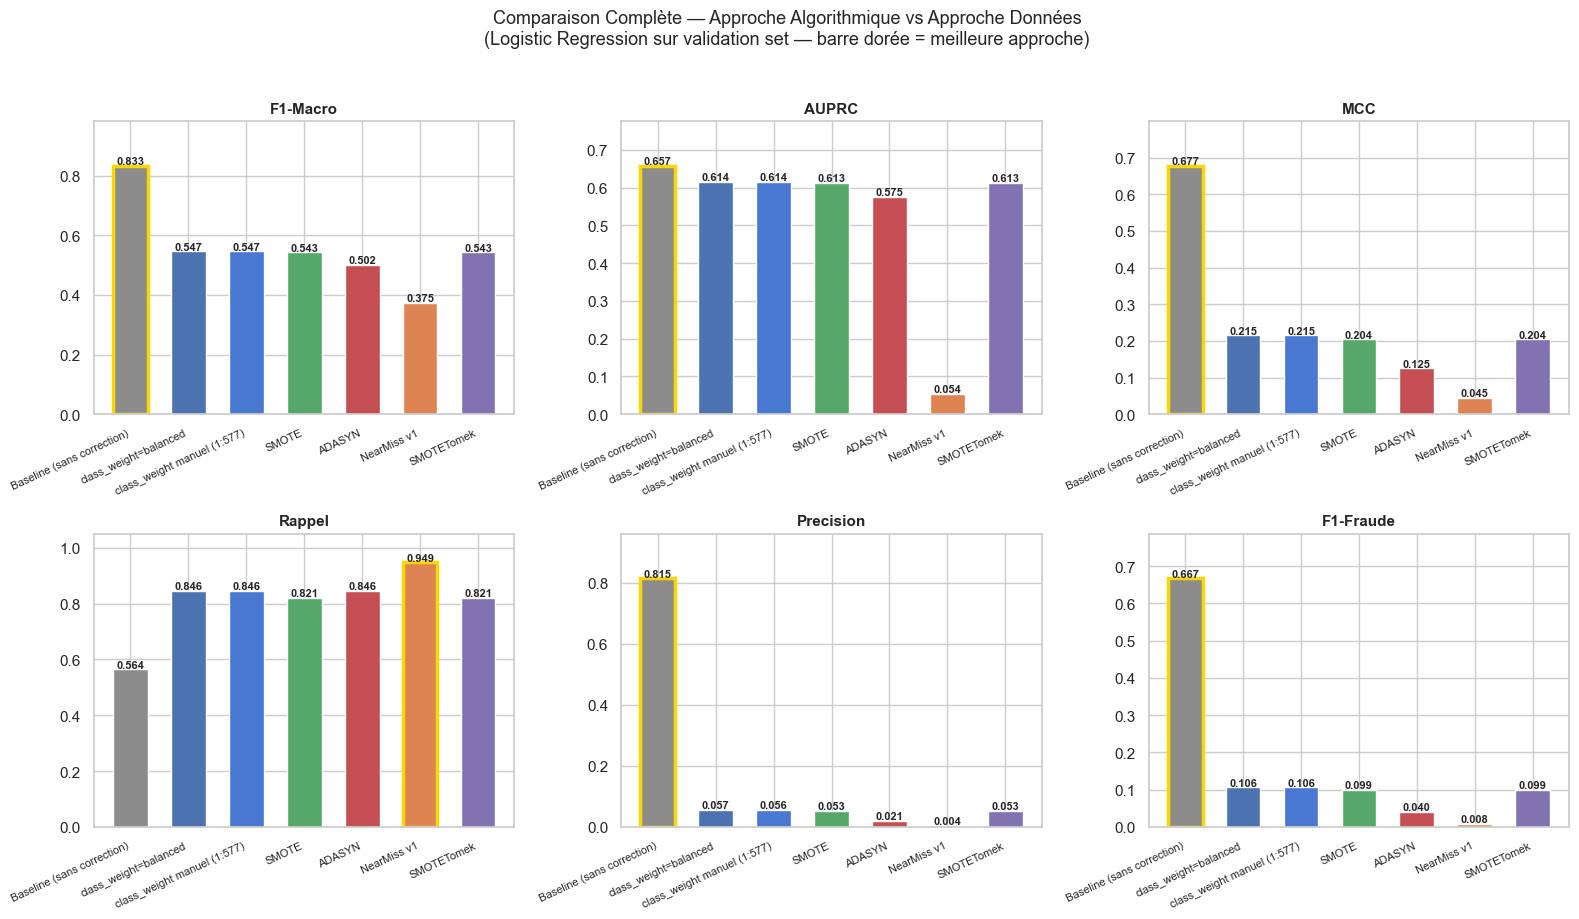

In [11]:
# ── Visualisation complète ────────────────────────────────────────
metrics_to_plot = ['F1-Macro', 'AUPRC', 'MCC', 'Rappel', 'Precision', 'F1-Fraude']
n_metrics = len(metrics_to_plot)
n_approaches = len(results_df)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

palette = ['#8C8C8C','#4C72B0','#4878CF','#55A868','#C44E52','#DD8452','#8172B2']

for i, metric in enumerate(metrics_to_plot):
    vals = results_df[metric]
    bars = axes[i].bar(range(len(vals)), vals.values,
                        color=palette[:len(vals)], edgecolor='white', width=0.6)
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(vals.index, rotation=25, ha='right', fontsize=8)
    axes[i].set_title(metric, fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, min(1.05, vals.max() * 1.18))
    # Best bar highlighted
    best_idx = vals.values.argmax()
    bars[best_idx].set_edgecolor('#FFD700')
    bars[best_idx].set_linewidth(2.5)
    for bar, v in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Comparaison Complète — Approche Algorithmique vs Approche Données\n'
             '(Logistic Regression sur validation set — barre dorée = meilleure approche)',
             fontsize=13, y=1.02)
plt.tight_layout()
os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/08_imbalance_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

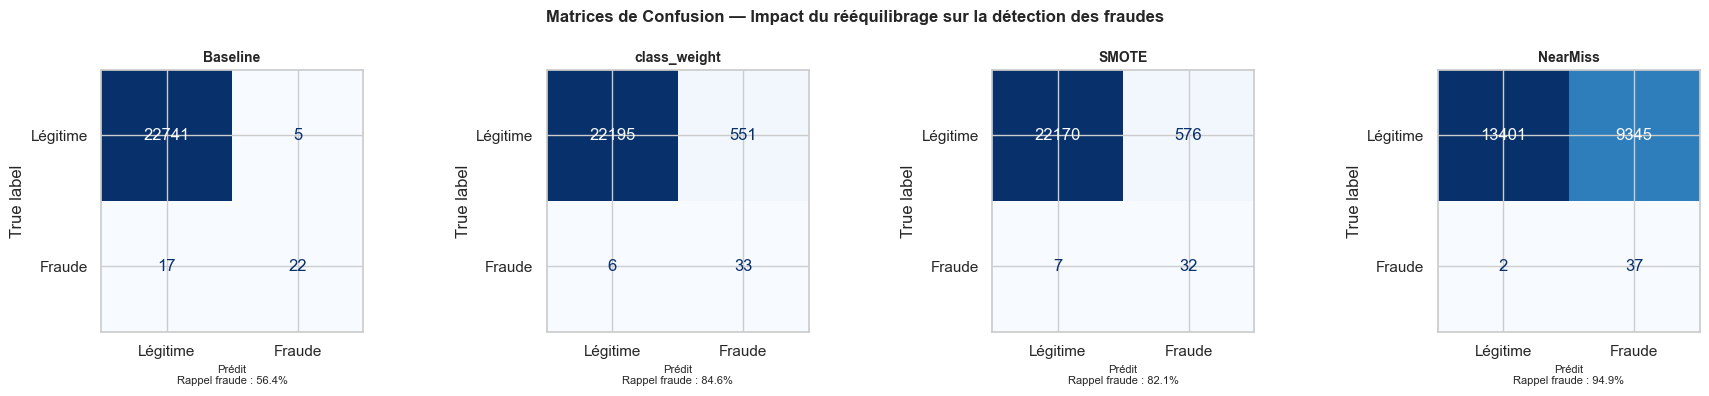

In [12]:
# ── Matrices de confusion côte à côte ────────────────────────────
models = [
    ('Baseline',        lr_base,     X_val_sc),
    ('class_weight',    lr_cw,       X_val_sc),
    ('SMOTE',           lr_sm,       X_val_sc),
    ('NearMiss',        lr_nm,       X_val_sc),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, model, X) in zip(axes, models):
    cm = confusion_matrix(y_val, model.predict(X))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Légitime','Fraude'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=10)
    # Annotate recall
    tp = cm[1,1]; fn = cm[1,0]
    recall = tp/(tp+fn) if (tp+fn) > 0 else 0
    ax.set_xlabel(f'Prédit\nRappel fraude : {recall:.1%}', fontsize=8)

plt.suptitle('Matrices de Confusion — Impact du rééquilibrage sur la détection des fraudes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/09_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

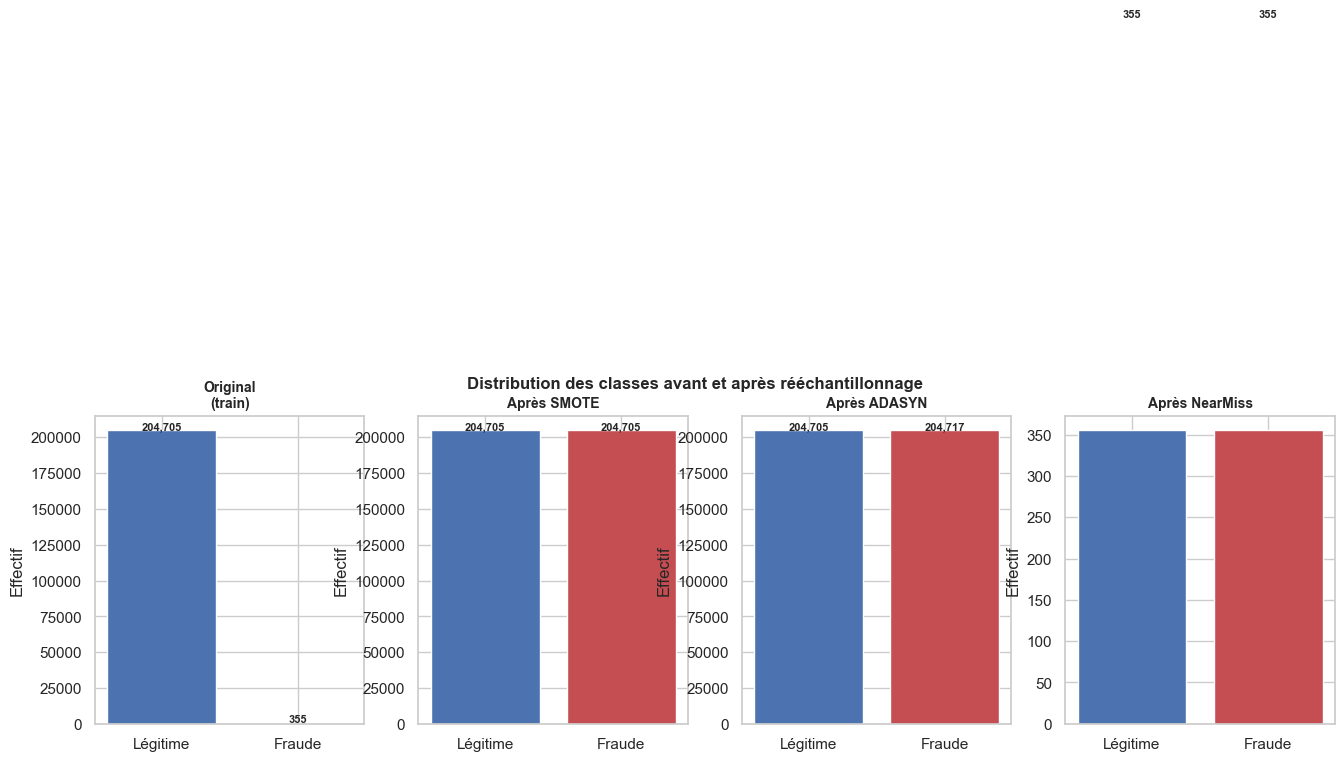

In [13]:
# ── Distribution avant / après rééchantillonnage ─────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

datasets = [
    ('Original\n(train)', y_train),
    ('Après SMOTE',       pd.Series(y_sm)),
    ('Après ADASYN',      pd.Series(y_ada)),
    ('Après NearMiss',    pd.Series(y_nm)),
]

for ax, (title, y) in zip(axes, datasets):
    counts = pd.Series(y).value_counts().sort_index()
    bars = ax.bar(['Légitime', 'Fraude'], counts.values,
                   color=['#4C72B0', '#C44E52'], edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel('Effectif')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{v:,}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Distribution des classes avant et après rééchantillonnage',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/10_resampling_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Export — `src/imbalance.py`
Fonctions réutilisables par tous les membres de l'équipe.

In [14]:
imbalance_code = '''
"""
src/imbalance.py
Pipeline de traitement du déséquilibre — Binôme B

Usage:
    from src.imbalance import apply_smote, apply_adasyn, get_class_weight

Règle: appliquer UNIQUEMENT sur X_train — jamais sur val ou test.
"""

from imblearn.over_sampling  import SMOTE, ADASYN
from imblearn.under_sampling import NearMiss
from imblearn.combine        import SMOTETomek
import numpy as np

RANDOM_SEED = 42


def apply_smote(X_train, y_train, seed=RANDOM_SEED):
    """
    Oversampling SMOTE — génère des exemples synthétiques
    par interpolation entre k voisins les plus proches.
    Résultat : classes équilibrées 1:1.
    """
    return SMOTE(random_state=seed).fit_resample(X_train, y_train)


def apply_adasyn(X_train, y_train, seed=RANDOM_SEED):
    """
    Oversampling ADASYN — comme SMOTE mais concentre
    la génération dans les zones difficiles à classifier.
    """
    return ADASYN(random_state=seed).fit_resample(X_train, y_train)


def apply_nearmiss(X_train, y_train, version=1):
    """
    Undersampling NearMiss — réduit la classe majoritaire.
    version=1 : garde les majoritaires proches des minoritaires.
    version=2 : garde les majoritaires loin des minoritaires.
    ⚠️  Perte d'information — à utiliser avec précaution.
    """
    return NearMiss(version=version).fit_resample(X_train, y_train)


def apply_smote_tomek(X_train, y_train, seed=RANDOM_SEED):
    """
    Approche combinée — SMOTE + suppression des Tomek links.
    Surcrée des exemples minoritaires et nettoie la frontière.
    """
    return SMOTETomek(random_state=seed).fit_resample(X_train, y_train)


def get_class_weight(y_train):
    """
    Retourne class_weight='balanced' pour sklearn.
    Usage: LogisticRegression(class_weight=get_class_weight(y_train))
           RandomForestClassifier(class_weight=get_class_weight(y_train))
    """
    return 'balanced'


def get_scale_pos_weight(y_train):
    """
    Retourne scale_pos_weight pour XGBoost.
    Formule : n_négatifs / n_positifs
    Usage: XGBClassifier(scale_pos_weight=get_scale_pos_weight(y_train))
    """
    counts = np.bincount(y_train)
    return counts[0] / counts[1]
'''

with open(f'{SRC_PATH}imbalance.py', 'w', encoding='utf-8') as f:
    f.write(imbalance_code.strip())

print('✅ src/imbalance.py exporté')
print('\nFonctions disponibles :')
for fn in ['apply_smote', 'apply_adasyn', 'apply_nearmiss',
           'apply_smote_tomek', 'get_class_weight', 'get_scale_pos_weight']:
    print(f'  from src.imbalance import {fn}')

✅ src/imbalance.py exporté

Fonctions disponibles :
  from src.imbalance import apply_smote
  from src.imbalance import apply_adasyn
  from src.imbalance import apply_nearmiss
  from src.imbalance import apply_smote_tomek
  from src.imbalance import get_class_weight
  from src.imbalance import get_scale_pos_weight


In [15]:
# ── Export src/evaluate.py (partagé avec Membre 1) ───────────────
evaluate_code = '''
"""
src/evaluate.py
Métriques partagées — à utiliser par tous les membres.
PAS d'accuracy — F1-Macro, AUPRC, MCC uniquement.

Usage:
    from src.evaluate import evaluate, print_report
"""

from sklearn.metrics import (
    f1_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
import pandas as pd


def evaluate(y_true, y_pred, y_proba, label='', verbose=True):
    """Calcule et retourne les métriques standard du projet."""
    f1    = f1_score(y_true, y_pred, average='macro')
    auprc = average_precision_score(y_true, y_proba)
    mcc   = matthews_corrcoef(y_true, y_pred)
    f1_fraud = f1_score(y_true, y_pred, average=None)[1]
    recall   = (y_pred[y_true == 1] == 1).mean()
    precision = (y_true[y_pred == 1] == 1).mean() if (y_pred==1).sum()>0 else 0

    if verbose:
        print(f"\n{'='*45}")
        print(f"  {label}")
        print(f"{'='*45}")
        print(f"  F1-Macro  : {f1:.4f}")
        print(f"  AUPRC     : {auprc:.4f}")
        print(f"  MCC       : {mcc:.4f}")
        print(f"  F1-Fraude : {f1_fraud:.4f}")
        print(f"  Rappel    : {recall:.4f} ({int(recall*y_true.sum())}/{y_true.sum()} fraudes)")
        print(f"  Précision : {precision:.4f}")

    return {
        'Modele'    : label,
        'F1-Macro'  : round(f1, 4),
        'AUPRC'     : round(auprc, 4),
        'MCC'       : round(mcc, 4),
        'F1-Fraude' : round(f1_fraud, 4),
        'Rappel'    : round(recall, 4),
        'Precision' : round(precision, 4),
    }


def compare_models(results_list):
    """Affiche un tableau comparatif propre de plusieurs modèles."""
    df = pd.DataFrame(results_list).set_index('Modele')
    print("\n" + "="*60)
    print("         COMPARAISON DES MODÈLES")
    print("="*60)
    print(df.to_string())
    return df
'''

with open(f'{SRC_PATH}evaluate.py', 'w', encoding='utf-8') as f:
    f.write(evaluate_code.strip())

print('✅ src/evaluate.py exporté')

✅ src/evaluate.py exporté


---
## 7. Résumé — À Copier dans le Rapport

| Approche | Type | F1-Macro | AUPRC | MCC | Rappel fraude |
|---|---|---|---|---|---|
| Baseline | — | *compléter* | *compléter* | *compléter* | *compléter* |
| class_weight | Algorithmique | *compléter* | *compléter* | *compléter* | *compléter* |
| SMOTE | Données | *compléter* | *compléter* | *compléter* | *compléter* |
| ADASYN | Données | *compléter* | *compléter* | *compléter* | *compléter* |
| NearMiss | Données | *compléter* | *compléter* | *compléter* | *compléter* |

### Recommandation pour chaque modèle :

| Modèle | Approche recommandée | Justification |
|---|---|---|
| Régression Logistique | `class_weight='balanced'` | Natif sklearn, pas de surcoût mémoire |
| Random Forest | `class_weight='balanced'` | Même raison |
| XGBoost | `scale_pos_weight` ou custom loss | Imposé par le cahier des charges |

### Règles rappelées :
1. SMOTE/ADASYN : `fit_resample` sur X_train UNIQUEMENT
2. Scaler : `fit` sur train, `transform` sur val et test
3. NearMiss : à documenter comme perte d'information intentionnelle
4. Ne jamais toucher test.csv avant la Phase 3